<a href="https://colab.research.google.com/github/Sharif2138/ML-techniques-1_Group-10_Formative-2/blob/main/Classical_ML_experiments/Traditional_Classical_Model_experimentation.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# SDG Indicator text classification Project
In this project, we are supposed to develop a machine learning system capable of classifying text documents according to the relevant indicators of Sustainable Development Goal 3 (SDG 3).

The dataset contains approximately 3,000 text samples collected from tenders, programs, reports, humanitarian initiatives, development organizations, and news articles related to international development and social impact work. Download the datasets from below.

## STEP 1: DATA LOADING AND PROBLEM UNDERSTANDING
Here we will
- load the both the training and testing dataset
- Understanding clearly the tasks (problem)
- Understanding the variables, both the X(independent) and Y(dependent)
- Have a clear structure of our data

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 62.6 MB/s eta 0:00:00


In [ ]:
import nltk
nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_rus to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |  

True

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn tools
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    hamming_loss,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# TOKENIZATION, AND OTHERS
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# GET TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

# GET word2vec
from gensim.models import Word2Vec



In [ ]:
df_train = pd.read_csv('/content/Devex_train.csv', encoding='latin1')
df_test = pd.read_csv('/content/Devex_test_questions.csv', encoding='latin1')

In [ ]:
df_train.head()

,Unique ID,Type,Text,Label 1,Label 2,Label 3,Label 4,Label 5,Label 6,Label 7,Label 8,Label 9,Label 10,Label 11,Label 12
0,12555,Grant,Centers of Biomedical Research Excellence (COB...,3.b.2 - Total net official development assista...,3.c.1 - Health worker density and distribution,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,14108,Grant,Research on Regenerative Medicine <h2><strong>...,3.b.2 - Total net official development assista...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,23168,Organization,Catholic Health Association of India (CHAI): <...,3.d.1 - International Health Regulations (IHR)...,3.8.1 - Coverage of essential health services ...,3.8.2 - Proportion of population with large ho...,3.b.3 - Proportion of health facilities that h...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,219512,Contract,Quality Improvement Initiatives for Diabetes,3.4.1 - Mortality rate attributed to cardiovas...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,274093,Tender,Provision of Thalassemia Drugs and Disposables...,3.3.5 - Number of people requiring interventio...,3.4.1 - Mortality rate attributed to cardiovas...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2995 entries, 0 to 2994
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Unique ID  2995 non-null   int64  
 1   Type       2995 non-null   object 
 2   Text       2995 non-null   object 
 3   Label 1    2995 non-null   object 
 4   Label 2    1635 non-null   object 
 5   Label 3    738 non-null    object 
 6   Label 4    312 non-null    object 
 7   Label 5    142 non-null    object 
 8   Label 6    59 non-null     object 
 9   Label 7    21 non-null     object 
 10  Label 8    10 non-null     object 
 11  Label 9    4 non-null      object 
 12  Label 10   2 non-null      object 
 13  Label 11   0 non-null      float64
 14  Label 12   0 non-null      float64
dtypes: float64(2), int64(1), object(12)
memory usage: 351.1+ KB


In [ ]:
df_train.describe()

,Unique ID,Label 11,Label 12
count,2995.000000,0.0,0.0
mean,127625.627045,NaN,NaN
std,114610.263542,NaN,NaN
min,719.000000,NaN,NaN
25%,13220.000000,NaN,NaN
50%,90900.000000,NaN,NaN
75%,256743.500000,NaN,NaN
max,295994.000000,NaN,NaN


In [ ]:
df_test.head()

,Unique ID,Type,Text
0,49848,Organization,4th Sector Health: <p>4th Sector Health is a U...
1,52348,Organization,Action for Global Health: <p>Action for Global...
2,103541,Organization,Scottish Association for Mental Health (SAMH):...
3,52382,Organization,Singapore Immunology Network: <p>The Singapore...
4,47212,Organization,Coastal Conservation and Education Foundation ...


In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 998 entries, 0 to 997
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Unique ID  998 non-null    int64 
 1   Type       998 non-null    object
 2   Text       998 non-null    object
dtypes: int64(1), object(2)
memory usage: 23.5+ KB


## STEP 2: Exploratory Data Analysis
Here we will,
- Understand our data more
- Identify the columns we need


In [ ]:
# UNDERSTANDING THE LABELS
label_cols = [f"Label {i}" for i in range(1, 13)]

label_cols

['Label 1',
 'Label 2',
 'Label 3',
 'Label 4',
 'Label 5',
 'Label 6',
 'Label 7',
 'Label 8',
 'Label 9',
 'Label 10',
 'Label 11',
 'Label 12']

In [ ]:
# CREATE COLUMN THAT WILL HAVE THE INDICATORS USED FOR EACH DOCUMENT
df_train["num_indicators"] = (
    df_train[label_cols]
    .notna()
    .sum(axis=1)
)

In [ ]:
# CREATE A COLUMN THAT WILL HAVE THE LIST OF ALL THE INDICATORS USED PER DOC
# SEPERATED BY ','
df_train["indicators"] = df_train[label_cols].apply(
    lambda row: ", ".join(row.dropna().astype(str)),
    axis=1
)

In [ ]:
df_train.head()

,Unique ID,Type,Text,Label 1,Label 2,Label 3,Label 4,Label 5,Label 6,Label 7,Label 8,Label 9,Label 10,Label 11,Label 12,num_indicators,indicators
0,12555,Grant,Centers of Biomedical Research Excellence (COB...,3.b.2 - Total net official development assista...,3.c.1 - Health worker density and distribution,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3.b.2 - Total net official development assista...
1,14108,Grant,Research on Regenerative Medicine <h2><strong>...,3.b.2 - Total net official development assista...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,3.b.2 - Total net official development assista...
2,23168,Organization,Catholic Health Association of India (CHAI): <...,3.d.1 - International Health Regulations (IHR)...,3.8.1 - Coverage of essential health services ...,3.8.2 - Proportion of population with large ho...,3.b.3 - Proportion of health facilities that h...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,3.d.1 - International Health Regulations (IHR)...
3,219512,Contract,Quality Improvement Initiatives for Diabetes,3.4.1 - Mortality rate attributed to cardiovas...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,3.4.1 - Mortality rate attributed to cardiovas...
4,274093,Tender,Provision of Thalassemia Drugs and Disposables...,3.3.5 - Number of people requiring interventio...,3.4.1 - Mortality rate attributed to cardiovas...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3.3.5 - Number of people requiring interventio...


In [ ]:
# EXTRACT JUST THE CODES AND LEAVE THE DESCRIPTIONS
# CREATE COLUMN indicators_codes TO STORE THESE CODES

# Separates by '-' and stores and index(0)
def extract_code(label):
    return str(label).split(" - ")[0]


df_train["indicator_codes"] = df_train[label_cols].apply(
    lambda row: ", ".join(
        [extract_code(x) for x in row.dropna()]
    ),
    axis=1
)

In [ ]:
df_train.head()

,Unique ID,Type,Text,Label 1,Label 2,Label 3,Label 4,Label 5,Label 6,Label 7,Label 8,Label 9,Label 10,Label 11,Label 12,num_indicators,indicators,indicator_codes
0,12555,Grant,Centers of Biomedical Research Excellence (COB...,3.b.2 - Total net official development assista...,3.c.1 - Health worker density and distribution,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3.b.2 - Total net official development assista...,"3.b.2, 3.c.1"
1,14108,Grant,Research on Regenerative Medicine <h2><strong>...,3.b.2 - Total net official development assista...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,3.b.2 - Total net official development assista...,3.b.2
2,23168,Organization,Catholic Health Association of India (CHAI): <...,3.d.1 - International Health Regulations (IHR)...,3.8.1 - Coverage of essential health services ...,3.8.2 - Proportion of population with large ho...,3.b.3 - Proportion of health facilities that h...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,3.d.1 - International Health Regulations (IHR)...,"3.d.1, 3.8.1, 3.8.2, 3.b.3"
3,219512,Contract,Quality Improvement Initiatives for Diabetes,3.4.1 - Mortality rate attributed to cardiovas...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,3.4.1 - Mortality rate attributed to cardiovas...,3.4.1
4,274093,Tender,Provision of Thalassemia Drugs and Disposables...,3.3.5 - Number of people requiring interventio...,3.4.1 - Mortality rate attributed to cardiovas...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3.3.5 - Number of people requiring interventio...,"3.3.5, 3.4.1"


In [ ]:
# PRINT TOTAL NUMBER OF INDICATORS
all_labels = []

for col in label_cols:
    all_labels.extend(
        df_train[col].dropna().tolist()
    )

unique_labels = sorted(set(all_labels))


print("Number of unique indicators:", len(unique_labels))

Number of unique indicators: 27


In [ ]:
# CREATE A NEW DATAFRAME TO STORE THE UNIQUE INDICATORS
indicator_df = pd.DataFrame(
    {"indicator": unique_labels}
)

indicator_df.head()

,indicator
0,3.1.1 - Maternal mortality ratio
1,3.1.2 - Proportion of births attended by skill...
2,3.2.1 - Under-5 mortality rate
3,3.2.2 - Neonatal mortality rate
4,"3.3.1 - Number of new HIV infections per 1,000..."


In [ ]:
# PRINT NUMBER OF TIMES THE INDICATOR APPEARS ON DOCS
from collections import Counter

counter = Counter(all_labels)

indicator_counts = pd.DataFrame(
    counter.items(),
    columns=["indicator", "count"]
)

indicator_counts = indicator_counts.sort_values(
    "count",
    ascending=False
)

indicator_counts.head(30).sort_values(by='count', ascending=False )

,indicator,count
0,3.b.2 - Total net official development assista...,1044
9,3.8.1 - Coverage of essential health services ...,531
2,3.4.1 - Mortality rate attributed to cardiovas...,485
5,3.b.3 - Proportion of health facilities that h...,397
10,"3.3.1 - Number of new HIV infections per 1,000...",372
12,3.2.1 - Under-5 mortality rate,249
8,3.c.1 - Health worker density and distribution,232
21,3.1.1 - Maternal mortality ratio,218
7,3.9.2 - Mortality rate attributed to unsafe wa...,218
1,3.d.1 - International Health Regulations (IHR)...,217


In [ ]:
indicator_counts['indicator_codes'] = indicator_counts['indicator'].apply(lambda x: extract_code(x))

In [ ]:
# PLOT THE B

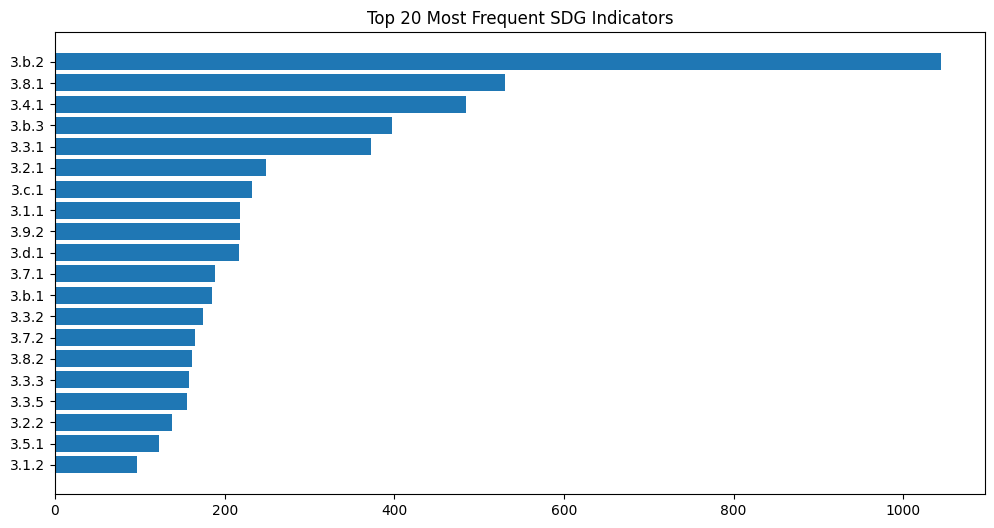

In [ ]:
import matplotlib.pyplot as plt

top20 = indicator_counts.head(20)

plt.figure(figsize=(12,6))
plt.barh(
    top20["indicator_codes"],
    top20["count"]
)
plt.gca().invert_yaxis()
plt.title("Top 20 Most Frequent SDG Indicators")
plt.show()

In [ ]:
df_train.head()

,Unique ID,Type,Text,Label 1,Label 2,Label 3,Label 4,Label 5,Label 6,Label 7,Label 8,Label 9,Label 10,Label 11,Label 12,num_indicators,indicators,indicator_codes
0,12555,Grant,Centers of Biomedical Research Excellence (COB...,3.b.2 - Total net official development assista...,3.c.1 - Health worker density and distribution,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3.b.2 - Total net official development assista...,"3.b.2, 3.c.1"
1,14108,Grant,Research on Regenerative Medicine <h2><strong>...,3.b.2 - Total net official development assista...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,3.b.2 - Total net official development assista...,3.b.2
2,23168,Organization,Catholic Health Association of India (CHAI): <...,3.d.1 - International Health Regulations (IHR)...,3.8.1 - Coverage of essential health services ...,3.8.2 - Proportion of population with large ho...,3.b.3 - Proportion of health facilities that h...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,3.d.1 - International Health Regulations (IHR)...,"3.d.1, 3.8.1, 3.8.2, 3.b.3"
3,219512,Contract,Quality Improvement Initiatives for Diabetes,3.4.1 - Mortality rate attributed to cardiovas...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,3.4.1 - Mortality rate attributed to cardiovas...,3.4.1
4,274093,Tender,Provision of Thalassemia Drugs and Disposables...,3.3.5 - Number of people requiring interventio...,3.4.1 - Mortality rate attributed to cardiovas...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3.3.5 - Number of people requiring interventio...,"3.3.5, 3.4.1"


In [ ]:
# PLOT NUMBER OF INDEXES PER DOC ON AVERAGE
df_train["num_indicators"].value_counts().sort_index()

,count
num_indicators,
1,1360
2,897
3,426
4,170
5,83
6,38
7,11
8,6
9,2


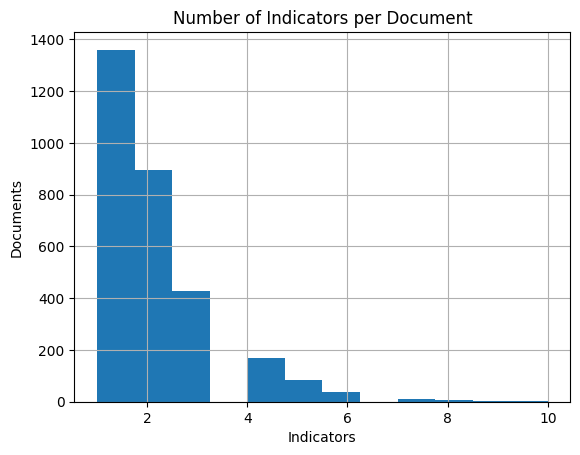

In [ ]:
df_train["num_indicators"].hist(
    bins=12
)

plt.title(
    "Number of Indicators per Document"
)

plt.xlabel("Indicators")
plt.ylabel("Documents")
plt.show()

### COMMENTS
We can see majority have 1 indicator followed by 2 and 3

In [ ]:
# CHECK THE DOCUMENT DESCRIPTION PER TYPE
df_train["Type"].value_counts()

,count
Type,
Tender,802
Grant,801
Contract,537
Open Opp,229
News,197
Funding Info,193
Organization,154
Program,82


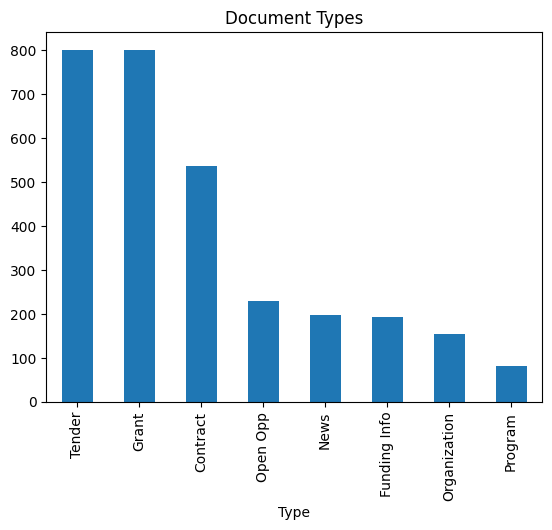

In [ ]:
df_train["Type"].value_counts().plot(
    kind="bar"
)

plt.title("Document Types")
plt.show()

In [ ]:
# Text Length Analysis
df_train["text_length_chars"] = (
    df_train["Text"]
    .astype(str)
    .str.len()
)

In [ ]:
df_train["text_length_words"] = (
    df_train["Text"]
    .astype(str)
    .str.split()
    .str.len()
)

In [ ]:
df_train[
    ["text_length_chars",
     "text_length_words"]
].describe()

,text_length_chars,text_length_words
count,2995.000000,2995.000000
mean,3820.610017,477.745242
std,5245.877776,641.966053
min,13.000000,2.000000
25%,131.000000,18.000000
50%,1670.000000,211.000000
75%,4794.000000,618.500000
max,31277.000000,3781.000000


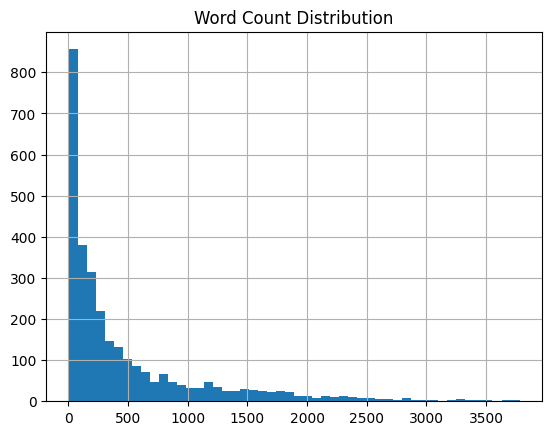

In [ ]:
df_train["text_length_words"].hist(
    bins=50
)

plt.title("Word Count Distribution")
plt.show()

In [ ]:
df_train.head(10)

,Unique ID,Type,Text,Label 1,Label 2,Label 3,Label 4,Label 5,Label 6,Label 7,Label 8,Label 9,Label 10,Label 11,Label 12,num_indicators,indicators,indicator_codes,text_length_chars,text_length_words
0,12555,Grant,Centers of Biomedical Research Excellence (COB...,3.b.2 - Total net official development assista...,3.c.1 - Health worker density and distribution,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3.b.2 - Total net official development assista...,"3.b.2, 3.c.1",3127,398
1,14108,Grant,Research on Regenerative Medicine <h2><strong>...,3.b.2 - Total net official development assista...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,3.b.2 - Total net official development assista...,3.b.2,2547,313
2,23168,Organization,Catholic Health Association of India (CHAI): <...,3.d.1 - International Health Regulations (IHR)...,3.8.1 - Coverage of essential health services ...,3.8.2 - Proportion of population with large ho...,3.b.3 - Proportion of health facilities that h...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,3.d.1 - International Health Regulations (IHR)...,"3.d.1, 3.8.1, 3.8.2, 3.b.3",2093,313
3,219512,Contract,Quality Improvement Initiatives for Diabetes,3.4.1 - Mortality rate attributed to cardiovas...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,3.4.1 - Mortality rate attributed to cardiovas...,3.4.1,44,5
4,274093,Tender,Provision of Thalassemia Drugs and Disposables...,3.3.5 - Number of people requiring interventio...,3.4.1 - Mortality rate attributed to cardiovas...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3.3.5 - Number of people requiring interventio...,"3.3.5, 3.4.1",3793,513
5,51151,Funding Info,Egypt Country Programme For Family Planning (2...,3.7.1 - Proportion of women of reproductive ag...,3.7.2 - Adolescent birth rate (aged 10_14 year...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3.7.1 - Proportion of women of reproductive ag...,"3.7.1, 3.7.2",3409,472
6,12265,Grant,Improving Quantification and Forecasting of Ne...,3.b.3 - Proportion of health facilities that h...,3.b.2 - Total net official development assista...,"3.3.2 - Tuberculosis incidence per 100,000 pop...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,3.b.3 - Proportion of health facilities that h...,"3.b.3, 3.b.2, 3.3.2",2127,307
7,14446,Grant,Call for Metrology for Emerging Radiopharmaceu...,3.b.2 - Total net official development assista...,3.4.1 - Mortality rate attributed to cardiovas...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3.b.2 - Total net official development assista...,"3.b.2, 3.4.1",100,12
8,14000,Grant,Funding to Stimulate Clinical and Translationa...,3.b.2 - Total net official development assista...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,3.b.2 - Total net official development assista...,3.b.2,1513,223
9,280626,Tender,Procurement of Radiopharmaceuticals for Treatm...,3.4.1 - Mortality rate attributed to cardiovas...,3.8.1 - Coverage of essential health services ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3.4.1 - Mortality rate attributed to cardiovas...,"3.4.1, 3.8.1",2985,394


### 2.B: Text Cleaning
- Clean the data by removing (non character, and others)
- Label encoding for numbers

Output:
- we expect clean texts

In [ ]:
# df_train.drop(columns=['clean_text',	'char_count',	'word_count'], inplace=True)

In [ ]:
df_train.head()

,Unique ID,Type,Text,Label 1,Label 2,Label 3,Label 4,Label 5,Label 6,Label 7,Label 8,Label 9,Label 10,Label 11,Label 12,num_indicators,indicators,indicator_codes,text_length_chars,text_length_words
0,12555,Grant,Centers of Biomedical Research Excellence (COB...,3.b.2 - Total net official development assista...,3.c.1 - Health worker density and distribution,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3.b.2 - Total net official development assista...,"3.b.2, 3.c.1",3127,398
1,14108,Grant,Research on Regenerative Medicine <h2><strong>...,3.b.2 - Total net official development assista...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,3.b.2 - Total net official development assista...,3.b.2,2547,313
2,23168,Organization,Catholic Health Association of India (CHAI): <...,3.d.1 - International Health Regulations (IHR)...,3.8.1 - Coverage of essential health services ...,3.8.2 - Proportion of population with large ho...,3.b.3 - Proportion of health facilities that h...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,3.d.1 - International Health Regulations (IHR)...,"3.d.1, 3.8.1, 3.8.2, 3.b.3",2093,313
3,219512,Contract,Quality Improvement Initiatives for Diabetes,3.4.1 - Mortality rate attributed to cardiovas...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,3.4.1 - Mortality rate attributed to cardiovas...,3.4.1,44,5
4,274093,Tender,Provision of Thalassemia Drugs and Disposables...,3.3.5 - Number of people requiring interventio...,3.4.1 - Mortality rate attributed to cardiovas...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3.3.5 - Number of people requiring interventio...,"3.3.5, 3.4.1",3793,513


In [ ]:
# PIPELINE FOR CLEANING RAW TEXTS
import re
import html
from bs4 import BeautifulSoup


def clean_text(text):
    """
    Basic text cleaning for Devex SDG dataset.
    Removes HTML artifacts and formatting noise
    while preserving linguistic content.
    """

    # Handle missing values
    if pd.isna(text):
        return ""

    # Convert to string
    text = str(text)

    # Decode HTML entities
    text = html.unescape(text)

    # Remove HTML tags
    text = BeautifulSoup(
        text,
        "html.parser"
    ).get_text(separator=" ")

    # Remove URLs
    text = re.sub(
        r'https?://\S+|www\.\S+',
        ' ',
        text
    )

    # Convert to lower case
    text = text.lower()

    # Remove email addresses
    text = re.sub(
        r'\S+@\S+',
        ' ',
        text
    )

    # Remove line breaks and tabs
    text = re.sub(
        r'[\r\n\t]',
        ' ',
        text
    )

    # Remove repeated whitespace
    text = re.sub(
        r'\s+',
        ' ',
        text
    )

    # Trim
    text = text.strip()

    # remove punctuations
    text = re.sub(r'[^\w\s]', ' ', text)

    # normalize spaces again
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [ ]:
df_train["clean_text"] = df_train["Text"].apply(clean_text)

df_test["clean_text"] = df_test["Text"].apply(clean_text)

In [ ]:
for i in range(3):
    print("="*100)

    print("ORIGINAL:")
    print(df_train["Text"].iloc[i][:500])

    print("\nCLEANED:")
    print(df_train["clean_text"].iloc[i][:500])

    print()

ORIGINAL:
Centers of Biomedical Research Excellence (COBRE) Phase III - Transitional Centers     <p><strong>Funding Opportunity Description</strong></p>    <p><a name="_Toc258873267"></a>The Institutional Development Award (IDeA) Program endeavors to stimulate research at institutions in states that have not traditionally received significant levels of research funding from the NIH. Created through congressional mandate, the IDeA Program broadens the geographic distribution of NIH funding for competitive 

CLEANED:
centers of biomedical research excellence cobre phase iii transitional centers funding opportunity description the institutional development award idea program endeavors to stimulate research at institutions in states that have not traditionally received significant levels of research funding from the nih created through congressional mandate the idea program broadens the geographic distribution of nih funding for competitive biomedical and behavioral research by enhancing t

In [ ]:
df_train["char_count"] = df_train["clean_text"].str.len()

df_train["word_count"] = (
    df_train["clean_text"]
    .str.split()
    .str.len()
)

In [ ]:
df_train.head()

,Unique ID,Type,Text,Label 1,Label 2,Label 3,Label 4,Label 5,Label 6,Label 7,...,Label 11,Label 12,num_indicators,indicators,indicator_codes,text_length_chars,text_length_words,clean_text,char_count,word_count
0,12555,Grant,Centers of Biomedical Research Excellence (COB...,3.b.2 - Total net official development assista...,3.c.1 - Health worker density and distribution,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2,3.b.2 - Total net official development assista...,"3.b.2, 3.c.1",3127,398,centers of biomedical research excellence cobr...,2883,407
1,14108,Grant,Research on Regenerative Medicine <h2><strong>...,3.b.2 - Total net official development assista...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1,3.b.2 - Total net official development assista...,3.b.2,2547,313,research on regenerative medicine introduction...,2214,314
2,23168,Organization,Catholic Health Association of India (CHAI): <...,3.d.1 - International Health Regulations (IHR)...,3.8.1 - Coverage of essential health services ...,3.8.2 - Proportion of population with large ho...,3.b.3 - Proportion of health facilities that h...,NaN,NaN,NaN,...,NaN,NaN,4,3.d.1 - International Health Regulations (IHR)...,"3.d.1, 3.8.1, 3.8.2, 3.b.3",2093,313,catholic health association of india chai the ...,1916,315
3,219512,Contract,Quality Improvement Initiatives for Diabetes,3.4.1 - Mortality rate attributed to cardiovas...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1,3.4.1 - Mortality rate attributed to cardiovas...,3.4.1,44,5,quality improvement initiatives for diabetes,44,5
4,274093,Tender,Provision of Thalassemia Drugs and Disposables...,3.3.5 - Number of people requiring interventio...,3.4.1 - Mortality rate attributed to cardiovas...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2,3.3.5 - Number of people requiring interventio...,"3.3.5, 3.4.1",3793,513,provision of thalassemia drugs and disposables...,3358,516


In [ ]:
for i in range(3):
    print("="*100)

    print("ORIGINAL:")
    print(df_test["Text"].iloc[i][:500])

    print("\nCLEANED:")
    print(df_test["clean_text"].iloc[i][:500])

    print()

ORIGINAL:
4th Sector Health: <p>4th Sector Health is a USAID initiative that forms Alliances and Exchanges to advance development through health in Latin America and the Caribbean. We mobilize business, the community and health experts to bring sustainable solutions to the public health issues that affect equitable development, such as maternal and child health, reproductive health, and diseases such as HIV/AIDS.</p>  <p>&nbsp;</p>  <p><strong>Solving Problems Together</strong></p>  <p>4th Sector Health s

CLEANED:
4th sector health 4th sector health is a usaid initiative that forms alliances and exchanges to advance development through health in latin america and the caribbean we mobilize business the community and health experts to bring sustainable solutions to the public health issues that affect equitable development such as maternal and child health reproductive health and diseases such as hiv aids solving problems together 4th sector health seeks to cultivate locally driven solu

### Comments:
I am keeping the numerical values as they present meaningful information

### LET'S BUILD Y


In [ ]:
# GET ALL THE LABELS
label_cols = [f"Label {i}" for i in range(1, 13)]

all_labels = []

for col in label_cols:
    all_labels.extend(df_train[col].dropna().tolist())

In [ ]:
all_labels

['3.b.2 - Total net official development assistance to medical research and basic health sector',
 '3.b.2 - Total net official development assistance to medical research and basic health sector',
 '3.d.1 - International Health Regulations (IHR) capacity and health emergency preparedness',
 '3.4.1 - Mortality rate attributed to cardiovascular disease, cancer, diabetes or chronic respiratory disease',
 '3.3.5 - Number of people requiring interventions against neglected tropical diseases',
 '3.7.1 - Proportion of women of reproductive age (aged 15_49 years) who have their need for family planning satisfied with modern methods',
 '3.b.3 - Proportion of health facilities that have a core set of relevant essential medicines available and affordable on a sustainable basis',
 '3.b.2 - Total net official development assistance to medical research and basic health sector',
 '3.b.2 - Total net official development assistance to medical research and basic health sector',
 '3.4.1 - Mortality rate a

In [ ]:
len(all_labels)

5918

In [ ]:
# extract just the codes
def extract_code(label):
    return str(label).split(" - ")[0].strip()

In [ ]:
unique_labels = sorted(set(extract_code(x) for x in all_labels))

In [ ]:
# perform label encoding
label_to_index = {
    label: idx
    for idx, label in enumerate(unique_labels)
}

In [ ]:
label_to_index

{'3.1.1': 0,
 '3.1.2': 1,
 '3.2.1': 2,
 '3.2.2': 3,
 '3.3.1': 4,
 '3.3.2': 5,
 '3.3.3': 6,
 '3.3.4': 7,
 '3.3.5': 8,
 '3.4.1': 9,
 '3.4.2': 10,
 '3.5.1': 11,
 '3.5.2': 12,
 '3.6.1': 13,
 '3.7.1': 14,
 '3.7.2': 15,
 '3.8.1': 16,
 '3.8.2': 17,
 '3.9.1': 18,
 '3.9.2': 19,
 '3.9.3': 20,
 '3.a.1': 21,
 '3.b.1': 22,
 '3.b.2': 23,
 '3.b.3': 24,
 '3.c.1': 25,
 '3.d.1': 26}

In [ ]:
# perform one hot encoding


num_labels = len(unique_labels)

def encode_labels(row):
    vector = np.zeros(num_labels)

    for col in label_cols:
        if pd.notna(row[col]):
            label = extract_code(row[col])
            if label in label_to_index:
                vector[label_to_index[label]] = 1

    return vector

In [ ]:
Y = np.array([
    encode_labels(row)
    for _, row in df_train.iterrows()
])

In [ ]:
Y.shape        # (3000, num_labels)

(2995, 27)

In [ ]:
Y

array([[0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 0., 1.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
df_train.shape

(2995, 23)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    df_train["clean_text"],
    Y,
    test_size=0.2,
    random_state=42
)

### NOTE:
Since Y is not a single class, or single label, but rather it is a binary vector (Bag of Words) showing which SDG indicators are present

**ex:**

- Doc 1 can belong to class 3.b.2, 3.c.1
- Doc 2 : 3.8.1, 3.4.1

So the full list of class is [3.b.2, 3.c.1, 3.8.1, 3.4.1]

To represent Y for our model to understand, we will assign the hot encoding for the entire dataset,

**ex after encoding:**

- Doc 1 = [1, 1, 0, 0]
- Doc 2 = [0, 0, 1, 1]

## STEP 3: Text Vectorization
Here we will
- tokenise the text by word (small tokens)
- remove stop words
- perform Lemmetisation

convert the texts to numbers,
for experiment we will use two techniques
1. TF-IDF
2. Word Embeddings

In [ ]:
# START WITH TOKENIZATION
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


In [ ]:
print(stop_words)

{'an', 'm', "we're", 'yourselves', 'as', 'for', "doesn't", 'does', "haven't", 'a', 'further', 'in', 'those', 'while', 'once', "should've", 'very', 'aren', 'him', 'any', 'same', 'why', "i've", 'each', 'should', 'at', "shouldn't", 'against', "it'll", 'be', 'haven', "he'd", 'having', 's', 'ours', 'itself', "wasn't", "i'll", 'is', 'to', 'what', 'herself', 'isn', 'their', 'from', "they'll", 'and', "we'll", 'than', 'myself', 'himself', "couldn't", 'then', 'ain', "don't", "you've", 'mightn', 'above', "shan't", 'them', 'of', 'had', "hasn't", 'that', 'your', 'has', 'was', 'again', 'between', 'off', 'who', 'which', 're', 'where', 'with', 'just', 'doing', 'until', 'weren', 'before', "i'd", 'how', 'its', 'over', "you'd", 'theirs', "she'd", 'too', "she's", 'my', 'y', 'no', 'hers', "we'd", 'under', 'all', "she'll", 'such', 'yours', 'only', 'ourselves', 'o', "didn't", "needn't", 'his', 'when', 'up', 'being', 'here', 'i', 'don', 'he', 'themselves', 'were', "it'd", 'our', 'can', 'both', "they've", 'her

In [ ]:
def preprocess_text(text):
    """
    Tokenization + Stopword removal + Lemmatization
    """

    tokens = word_tokenize(str(text))

    tokens = [
        lemmatizer.lemmatize(token.lower())
        for token in tokens
        if token.isalpha() and token.lower() not in stop_words
    ]

    return tokens

#### PIPELINE 1 — TF-IDF REPRESENTATION

In [ ]:
# run the preprocess function for tokenization
df_train["tokens"] = df_train['clean_text'].apply(preprocess_text)
df_train["processed_text"] = df_train["tokens"].apply(
    lambda x: " ".join(x)
)

#### Comments

Because tf-idf performs it's own tokenizer, we need to rejoin the tokens back to sentences or strings

In [ ]:
# apply on test set as well
df_test["tokens"] = df_test['clean_text'].apply(preprocess_text)
df_test["processed_text"] = df_test["tokens"].apply(
    lambda x: " ".join(x)
)

In [ ]:
df_test

,Unique ID,Type,Text,clean_text,tokens,processed_text
0,49848,Organization,4th Sector Health: <p>4th Sector Health is a U...,4th sector health 4th sector health is a usaid...,"[sector, health, sector, health, usaid, initia...",sector health sector health usaid initiative f...
1,52348,Organization,Action for Global Health: <p>Action for Global...,action for global health action for global hea...,"[action, global, health, action, global, healt...",action global health action global health afgh...
2,103541,Organization,Scottish Association for Mental Health (SAMH):...,scottish association for mental health samh ar...,"[scottish, association, mental, health, samh, ...",scottish association mental health samh around...
3,52382,Organization,Singapore Immunology Network: <p>The Singapore...,singapore immunology network the singapore imm...,"[singapore, immunology, network, singapore, im...",singapore immunology network singapore immunol...
4,47212,Organization,Coastal Conservation and Education Foundation ...,coastal conservation and education foundation ...,"[coastal, conservation, education, foundation,...",coastal conservation education foundation ccef...
...,...,...,...,...,...,...
993,38108,Program,\r Ulaanbaatar Air Quality Improvement Program...,ulaanbaatar air quality improvement program th...,"[ulaanbaatar, air, quality, improvement, progr...",ulaanbaatar air quality improvement program go...
994,30360,Program,Supporting National Urban Health Mission<p>Thr...,supporting national urban health mission throu...,"[supporting, national, urban, health, mission,...",supporting national urban health mission proje...
995,33883,Program,WHO Contingency Fund - 2015<p>The project aims...,who contingency fund 2015 the project aims to ...,"[contingency, fund, project, aim, support, con...",contingency fund project aim support contingen...
996,36296,Program,Lebanon Health Resilience Project<p>The projec...,lebanon health resilience project the project ...,"[lebanon, health, resilience, project, project...",lebanon health resilience project project deve...


In [ ]:
print(df_train['Text'][0])
print(df_train['clean_text'][0])
print(df_train['tokens'][0])
print(df_train['processed_text'][0])

Centers of Biomedical Research Excellence (COBRE) Phase III - Transitional Centers     <p><strong>Funding Opportunity Description</strong></p>    <p><a name="_Toc258873267"></a>The Institutional Development Award (IDeA) Program endeavors to stimulate research at institutions in states that have not traditionally received significant levels of research funding from the NIH. Created through congressional mandate, the IDeA Program broadens the geographic distribution of NIH funding for competitive biomedical and behavioral research by enhancing the research capabilities of institutions in eligible states. The IDeA Program aims to achieve this goal through two major initiatives: (1) the IDeA Networks of Biomedical Research Excellence (INBRE), and (2) the Centers of Biomedical Research Excellence (COBRE).</p>    <p>The COBRE initiative seeks to develop unique, innovative, multidisciplinary, and collaborative state-of-the-art biomedical and behavioral research centers focused on a scientific

In [ ]:
# Step 2: TF-IDF Vectorization

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)   # captures phrases like "health system"
)

X_tfidf = tfidf.fit_transform(df_train["processed_text"])

In [ ]:
# tranform test set as well
X_test_tfidf = tfidf.fit_transform(df_test['processed_text'])

In [ ]:
X_tfidf.shape  # (num_samples, vocab_size)

(2995, 5000)

In [ ]:
X_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 488306 stored elements and shape (2995, 5000)>

In [ ]:
X_test_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 171575 stored elements and shape (998, 5000)>

In [ ]:
# PERFORM TRAINING AND VALIDATION SPLIT
X_train_tfidf, X_val_tfidf, y_train, y_val = train_test_split(
    X_tfidf,
    Y,
    test_size=0.2,
    random_state=42
)

#### PIPELINE 2 — WORD EMBEDDINGS REPRESENTATION


In [ ]:
sentences = df_train["tokens"].tolist()

w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=200,
    window=5,
    min_count=2,
    workers=4
)

In [ ]:

def document_vector(tokens):
    vectors = [
        w2v_model.wv[word]
        for word in tokens
        if word in w2v_model.wv
    ]

    if len(vectors) == 0:
        return np.zeros(200)

    return np.mean(vectors, axis=0)

In [ ]:
X_w2v = np.array([
    document_vector(tokens)
    for tokens in df_train["tokens"]
])

In [ ]:
X_w2v.shape

(2995, 200)

In [ ]:
# Convert testing set as well
sentences = df_test["tokens"].tolist()

w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=200,
    window=5,
    min_count=2,
    workers=4
)


def document_vector(tokens):
    vectors = [
        w2v_model.wv[word]
        for word in tokens
        if word in w2v_model.wv
    ]

    if len(vectors) == 0:
        return np.zeros(200)

    return np.mean(vectors, axis=0)


X_test_w2v = np.array([
    document_vector(tokens)
    for tokens in df_test["tokens"]
])

In [ ]:
X_test_w2v.shape

(998, 200)

In [ ]:
X_train_w2v, X_val_w2v, y_train_w2v, y_val_w2v = train_test_split(
    X_w2v,
    Y,
    test_size=0.2,
    random_state=42
)

## STEP 4: Model Training
We will choose the the three models we learnt for classification, that is
1. RNN
2. LSTM
3. GRU

optionally we can choose one traditional model
- Logistic Regression
- SVM
- Naive Bayes

Then additionally we can use
- Cosine similarity


In [ ]:
def evaluate_model(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    model_name
):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)

    print("=" * 80)
    print(model_name)
    print("=" * 80)

    print(f"Hamming Loss : {hamming_loss(y_val, y_pred):.4f}")
    print(f"Accuracy     : {accuracy_score(y_val, y_pred):.4f}")

    print(
        f"Precision(Macro): "
        f"{precision_score(y_val, y_pred, average='macro', zero_division=0):.4f}"
    )

    print(
        f"Recall(Macro): "
        f"{recall_score(y_val, y_pred, average='macro', zero_division=0):.4f}"
    )

    print(
        f"F1(Macro): "
        f"{f1_score(y_val, y_pred, average='macro', zero_division=0):.4f}"
    )

    print(
        "\nClassification Report:\n"
    )

    print(
        classification_report(
            y_val,
            y_pred,
            zero_division=0
        )
    )

    return y_pred

In [ ]:
from sklearn.metrics import multilabel_confusion_matrix

def plot_confusion_matrices(
    y_true,
    y_pred,
    labels,
    max_labels=9
):

    cms = multilabel_confusion_matrix(
        y_true,
        y_pred
    )

    plt.figure(
        figsize=(15,10)
    )

    for i in range(
        min(max_labels, len(labels))
    ):

        plt.subplot(
            3,
            3,
            i+1
        )

        sns.heatmap(
            cms[i],
            annot=True,
            fmt='d',
            cmap='Blues'
        )

        plt.title(labels[i])

    plt.tight_layout()
    plt.show()

#### Experiment 1: TF-IDF + Logistic Regression

In [ ]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression

lr_tfidf = OneVsRestClassifier(
    LogisticRegression(
        max_iter=1000,
        random_state=42
    )
)

score_lr_tfidf = evaluate_model(
    lr_tfidf,
    X_train_tfidf,
    y_train,
    X_val_tfidf,
    y_val,
    "TF-IDF + Logistic Regression"
)

TF-IDF + Logistic Regression
Hamming Loss : 0.0532
Accuracy     : 0.2671
Precision(Macro): 0.7178
Recall(Macro): 0.1940
F1(Macro): 0.2873

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.20      0.33        30
           1       0.00      0.00      0.00        18
           2       0.85      0.24      0.38        45
           3       1.00      0.05      0.10        19
           4       1.00      0.53      0.69        78
           5       1.00      0.26      0.41        47
           6       1.00      0.38      0.55        45
           7       0.00      0.00      0.00        17
           8       1.00      0.15      0.26        34
           9       0.94      0.47      0.63        93
          10       0.00      0.00      0.00        11
          11       0.67      0.12      0.21        16
          12       1.00      0.07      0.12        15
          13       0.00      0.00      0.00         3
          14       0.93   

#### Experiment 2: TF-IDF + Linear SVM

In [ ]:
from sklearn.svm import LinearSVC

svm_tfidf = OneVsRestClassifier(
    LinearSVC(
        random_state=42
    )
)

score_svm_tfidf = evaluate_model(
    svm_tfidf,
    X_train_tfidf,
    y_train,
    X_val_tfidf,
    y_val,
    "TF-IDF + Linear SVM"
)

TF-IDF + Linear SVM
Hamming Loss : 0.0450
Accuracy     : 0.3756
Precision(Macro): 0.8090
Recall(Macro): 0.4288
F1(Macro): 0.5420

Classification Report:

              precision    recall  f1-score   support

           0       0.68      0.43      0.53        30
           1       0.40      0.11      0.17        18
           2       0.79      0.42      0.55        45
           3       0.60      0.16      0.25        19
           4       0.97      0.76      0.85        78
           5       0.97      0.60      0.74        47
           6       0.97      0.62      0.76        45
           7       1.00      0.18      0.30        17
           8       0.74      0.50      0.60        34
           9       0.94      0.62      0.75        93
          10       0.75      0.27      0.40        11
          11       0.82      0.56      0.67        16
          12       0.86      0.40      0.55        15
          13       1.00      0.67      0.80         3
          14       0.84      0.60  

#### Experiment 3: Word2Vec + Logistic Regression

In [ ]:
lr_w2v = OneVsRestClassifier(
    LogisticRegression(
        max_iter=1000,
        random_state=42
    )
)

score_lr_w2v = evaluate_model(
    lr_w2v,
    X_train_w2v,
    y_train,
    X_val_w2v,
    y_val,
    "Word2Vec + Logistic Regression"
)

Word2Vec + Logistic Regression
Hamming Loss : 0.0593
Accuracy     : 0.2254
Precision(Macro): 0.4942
Recall(Macro): 0.1600
F1(Macro): 0.2265

Classification Report:

              precision    recall  f1-score   support

           0       0.36      0.17      0.23        30
           1       0.00      0.00      0.00        18
           2       0.57      0.18      0.27        45
           3       0.00      0.00      0.00        19
           4       0.85      0.53      0.65        78
           5       0.89      0.34      0.49        47
           6       0.78      0.16      0.26        45
           7       0.00      0.00      0.00        17
           8       0.83      0.15      0.25        34
           9       0.85      0.49      0.63        93
          10       0.00      0.00      0.00        11
          11       0.33      0.12      0.18        16
          12       0.00      0.00      0.00        15
          13       0.00      0.00      0.00         3
          14       0.80 

#### Experiment 4: Word2Vec + Linear SVM

In [ ]:
svm_w2v = OneVsRestClassifier(
    LinearSVC(
        random_state=42
    )
)

score_svm_w2v = evaluate_model(
    svm_w2v,
    X_train_w2v,
    y_train,
    X_val_w2v,
    y_val,
    "Word2Vec + Linear SVM"
)

Word2Vec + Linear SVM
Hamming Loss : 0.0577
Accuracy     : 0.2487
Precision(Macro): 0.5188
Recall(Macro): 0.1812
F1(Macro): 0.2508

Classification Report:

              precision    recall  f1-score   support

           0       0.46      0.20      0.28        30
           1       0.00      0.00      0.00        18
           2       0.56      0.20      0.30        45
           3       0.00      0.00      0.00        19
           4       0.92      0.62      0.74        78
           5       1.00      0.38      0.55        47
           6       0.79      0.24      0.37        45
           7       0.00      0.00      0.00        17
           8       1.00      0.15      0.26        34
           9       0.83      0.54      0.65        93
          10       0.00      0.00      0.00        11
          11       0.44      0.25      0.32        16
          12       0.00      0.00      0.00        15
          13       0.00      0.00      0.00         3
          14       0.83      0.29

#### Experiment 5: TF-IDF + Cosine Similarity

In [ ]:
import numpy as np

label_centroids_tfidf = []

for i in range(y_train.shape[1]):

    label_docs = X_train_tfidf[y_train[:, i] == 1]

    centroid = label_docs.mean(axis=0)

    label_centroids_tfidf.append(centroid)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def cosine_predict_tfidf(X, centroids, threshold=0.2):

    predictions = []

    centroids_matrix = np.vstack([
        np.asarray(c).ravel()
        for c in centroids
    ])

    for doc in X:

        doc_dense = doc.toarray()

        sims = cosine_similarity(
            doc_dense,
            centroids_matrix
        )[0]

        pred = (sims >= threshold).astype(int)

        predictions.append(pred)

    return np.array(predictions)

In [ ]:
y_pred_cos_tfidf = cosine_predict_tfidf(
    X_val_tfidf,
    label_centroids_tfidf,
    threshold=0.2
)

score_cos_tfidf = hamming_loss(
    y_val,
    y_pred_cos_tfidf
)

print("TF-IDF + Cosine Similarity")
print("Hamming Loss:", score_cos_tfidf)

TF-IDF + Cosine Similarity
Hamming Loss: 0.1715822667408644


#### Experiment 6: Word2Vec + Cosine Similarity

In [ ]:
label_centroids_w2v = []

for i in range(y_train.shape[1]):

    label_vectors = X_train_w2v[
        y_train[:, i] == 1
    ]

    centroid = label_vectors.mean(axis=0)

    label_centroids_w2v.append(centroid)

In [ ]:
def cosine_predict_w2v(
    X,
    centroids,
    threshold=0.3
):

    centroids = np.array(centroids)

    predictions = []

    for doc in X:

        sims = cosine_similarity(
            doc.reshape(1,-1),
            centroids
        )[0]

        pred = (sims >= threshold).astype(int)

        predictions.append(pred)

    return np.array(predictions)

In [ ]:
y_pred_cos_w2v = cosine_predict_w2v(
    X_val_w2v,
    label_centroids_w2v,
    threshold=0.3
)

score_cos_w2v = hamming_loss(
    y_val,
    y_pred_cos_w2v
)

print("Word2Vec + Cosine Similarity")
print("Hamming Loss:", score_cos_w2v)

Word2Vec + Cosine Similarity
Hamming Loss: 0.9047177394422803


In [ ]:
index_to_label = {
    idx: label
    for label, idx
    in label_to_index.items()
}

In [ ]:
def decode_prediction(row):

    labels = []

    for idx, value in enumerate(row):

        if value == 1:
            labels.append(
                index_to_label[idx]
            )

    return labels

### Deep Learning experiments
**NOTE:**
My experiments were on traditional Classical Models, I conducted these deep learning experiments out of learning, for deep learning experiments, refer to Innocent's notebook. And that's why it is not included in my analysis for traditional Classical models

#### Word Embedding dor deep learning models

In [ ]:
df_train

,Unique ID,Type,Text,Label 1,Label 2,Label 3,Label 4,Label 5,Label 6,Label 7,...,num_indicators,indicators,indicator_codes,text_length_chars,text_length_words,clean_text,char_count,word_count,tokens,processed_text
0,12555,Grant,Centers of Biomedical Research Excellence (COB...,3.b.2 - Total net official development assista...,3.c.1 - Health worker density and distribution,NaN,NaN,NaN,NaN,NaN,...,2,3.b.2 - Total net official development assista...,"3.b.2, 3.c.1",3127,398,centers of biomedical research excellence cobr...,2883,407,"[center, biomedical, research, excellence, cob...",center biomedical research excellence cobre ph...
1,14108,Grant,Research on Regenerative Medicine <h2><strong>...,3.b.2 - Total net official development assista...,NaN,NaN,NaN,NaN,NaN,NaN,...,1,3.b.2 - Total net official development assista...,3.b.2,2547,313,research on regenerative medicine introduction...,2214,314,"[research, regenerative, medicine, introductio...",research regenerative medicine introduction su...
2,23168,Organization,Catholic Health Association of India (CHAI): <...,3.d.1 - International Health Regulations (IHR)...,3.8.1 - Coverage of essential health services ...,3.8.2 - Proportion of population with large ho...,3.b.3 - Proportion of health facilities that h...,NaN,NaN,NaN,...,4,3.d.1 - International Health Regulations (IHR)...,"3.d.1, 3.8.1, 3.8.2, 3.b.3",2093,313,catholic health association of india chai the ...,1916,315,"[catholic, health, association, india, chai, c...",catholic health association india chai catholi...
3,219512,Contract,Quality Improvement Initiatives for Diabetes,3.4.1 - Mortality rate attributed to cardiovas...,NaN,NaN,NaN,NaN,NaN,NaN,...,1,3.4.1 - Mortality rate attributed to cardiovas...,3.4.1,44,5,quality improvement initiatives for diabetes,44,5,"[quality, improvement, initiative, diabetes]",quality improvement initiative diabetes
4,274093,Tender,Provision of Thalassemia Drugs and Disposables...,3.3.5 - Number of people requiring interventio...,3.4.1 - Mortality rate attributed to cardiovas...,NaN,NaN,NaN,NaN,NaN,...,2,3.3.5 - Number of people requiring interventio...,"3.3.5, 3.4.1",3793,513,provision of thalassemia drugs and disposables...,3358,516,"[provision, thalassemia, drug, disposable, bac...",provision thalassemia drug disposable backgrou...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2990,92153,News,How rats could help reduce the global TB burden:,"3.3.2 - Tuberculosis incidence per 100,000 pop...",NaN,NaN,NaN,NaN,NaN,NaN,...,1,"3.3.2 - Tuberculosis incidence per 100,000 pop...",3.3.2,48,9,how rats could help reduce the global tb burden,47,9,"[rat, could, help, reduce, global, tb, burden]",rat could help reduce global tb burden
2991,1209,Open Opp,Exploratory Analyses of Adherence Strategies a...,3.b.2 - Total net official development assista...,NaN,NaN,NaN,NaN,NaN,NaN,...,1,3.b.2 - Total net official development assista...,3.b.2,17838,2120,exploratory analyses of adherence strategies a...,14026,2098,"[exploratory, analysis, adherence, strategy, d...",exploratory analysis adherence strategy data s...
2992,14342,Grant,Study on Vaccines for Diarrhoeal Diseases or L...,3.b.1 - Proportion of the target population co...,3.b.2 - Total net official development assista...,3.3.5 - Number of people requiring interventio...,NaN,NaN,NaN,NaN,...,3,3.b.1 - Proportion of the target population co...,"3.b.1, 3.b.2, 3.3.5",743,94,study on vaccines for diarrhoeal diseases or l...,683,94,"[study, vaccine, diarrhoeal, disease, lower, r...",study vaccine diarrhoeal disease lower respira...
2993,12353,Grant,Regional Engagement Stimulation Fund on Human ...,"3.3.1 - Number of new HIV infections per 1,000...",NaN,NaN,NaN,NaN,NaN,NaN,...,1,"3.3.1 - Number of new HIV infections per 1,000...",3.3.1,3645,535,regional engagement stimulation fund on human ...,3512,549,"[regional, engagement, stimulation, fund, huma...",regional engagement stimulation fund human imm...


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    df_train['processed_text'], Y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 50000
max_len = 200

tokenizer = Tokenizer(num_words=max_words, oov_token="<UNK>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post")
X_val_pad   = pad_sequences(X_val_seq, maxlen=max_len, padding="post")

In [ ]:
# Train Word2Vec
sentences = [text.split() for text in X_train]

w2v = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

In [ ]:
# Build embedding matrix
vocab = tokenizer.word_index
embedding_dim = 100

embedding_matrix = np.zeros((max_words, embedding_dim))

for word, i in vocab.items():
    if i < max_words and word in w2v.wv:
        embedding_matrix[i] = w2v.wv[word]

In [ ]:
# MODEL BASE: EMBEDDING LAYER
import tensorflow as tf

embedding_layer = tf.keras.layers.Embedding(
    input_dim=max_words,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    input_length=max_len,
    trainable=True
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


#### Deep Learning-Experiment1: Build LSTM model

In [ ]:
def build_lstm():
    inputs = tf.keras.Input(shape=(max_len,))

    x = embedding_layer(inputs)
    x = tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(128)
    )(x)

    outputs = tf.keras.layers.Dense(Y.shape[1], activation="sigmoid")(x)

    return tf.keras.Model(inputs, outputs)

In [ ]:
# COMPILE MODEL

model = build_lstm()

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# TRAINING
history = model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.1978 - loss: 0.2669 - val_accuracy: 0.2437 - val_loss: 0.2187
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.2759 - loss: 0.2123 - val_accuracy: 0.3022 - val_loss: 0.2046
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.3439 - loss: 0.1961 - val_accuracy: 0.3539 - val_loss: 0.1930
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.3840 - loss: 0.1855 - val_accuracy: 0.3639 - val_loss: 0.1867
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.4199 - loss: 0.1745 - val_accuracy: 0.4157 - val_loss: 0.1784
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.4270 - loss: 0.1648 - val_accuracy: 0.4073 - val_loss: 0.1763
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.4812 - loss: 0.1531 - val_accuracy: 0.4374 - val_loss: 0.1704
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.5046 - loss: 0.1426 - val_accuracy: 0.4357 - v

#### EXPERIMENT 2 — IMPROVED LSTM

In [ ]:
def build_lstm_v2():
    inputs = tf.keras.Input(shape=(max_len,))

    # Embedding layer (same as before)
    x = embedding_layer(inputs)

    # 🔥 FIRST LSTM LAYER (returns full sequence)
    x = tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(
            256,
            return_sequences=True,
            dropout=0.3,
            recurrent_dropout=0.2
        )
    )(x)

    # 🔥 SECOND LSTM LAYER (compressed representation)
    x = tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(
            128,
            return_sequences=True,
            dropout=0.3,
            recurrent_dropout=0.2
        )
    )(x)

    # 🔥 GLOBAL FEATURE EXTRACTION (VERY IMPORTANT IMPROVEMENT)
    avg_pool = tf.keras.layers.GlobalAveragePooling1D()(x)
    max_pool = tf.keras.layers.GlobalMaxPooling1D()(x)

    x = tf.keras.layers.Concatenate()([avg_pool, max_pool])

    # 🔥 DENSE LAYER FOR NONLINEAR COMBINATION
    x = tf.keras.layers.Dense(256, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.4)(x)

    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.3)(x)

    # OUTPUT LAYER (multi-label)
    outputs = tf.keras.layers.Dense(
        Y.shape[1],
        activation="sigmoid"
    )(x)

    model = tf.keras.Model(inputs, outputs)

    return model

In [ ]:
model_v2 = build_lstm_v2()

model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-4),  # lower LR = more stable
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# TRAINING
history_v2 = model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.5927 - loss: 0.1089 - val_accuracy: 0.4808 - val_loss: 0.1661
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.6202 - loss: 0.0981 - val_accuracy: 0.4524 - val_loss: 0.1659
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.6365 - loss: 0.0878 - val_accuracy: 0.4508 - val_loss: 0.1702
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.6498 - loss: 0.0790 - val_accuracy: 0.4524 - val_loss: 0.1741
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.6507 - loss: 0.0715 - val_accuracy: 0.4624 - val_loss: 0.1776
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.6532 - loss: 0.0662 - val_accuracy: 0.4608 - val_loss: 0.1815
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.6532 - loss: 0.0588 - val_accuracy: 0.4608 - val_loss: 0.1872
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.6653 - loss: 0.0539 - val_accuracy: 0.4591 - v

## STEP 6: Evaluation
We will then perform evaluation in
1. plotting training and validation loss and accuracy
2. Use the different metrics
    -  Accuracy, precision, recall, f1-score
    - Confussion matrix


#### Experiment1- Results

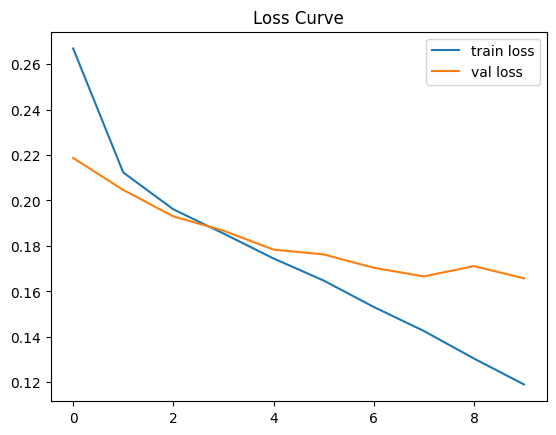

In [ ]:
# PLOT TRAINING CURVES
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

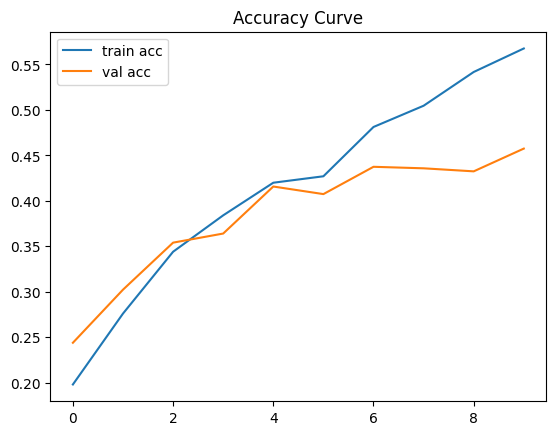

In [ ]:
plt.plot(history.history["accuracy"], label="train acc")
plt.plot(history.history["val_accuracy"], label="val acc")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

#### PREDICTIONS

In [ ]:
y_pred_prob = model.predict(X_val_pad)
y_pred = (y_pred_prob > 0.5).astype(int)

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


#### MAIN METRIC: HAMMING LOSS

In [ ]:
hl = hamming_loss(y_val, y_pred)
print("Hamming Loss:", hl)

Hamming Loss: 0.05768874049341495


#### FULL METRICS

In [ ]:
print("F1 (macro):", f1_score(y_val, y_pred, average="macro"))
print("Precision:", precision_score(y_val, y_pred, average="macro"))
print("Recall:", recall_score(y_val, y_pred, average="macro"))
print("Accuracy:", accuracy_score(y_val, y_pred))

F1 (macro): 0.26739582768652037
Precision: 0.47222614368044735
Recall: 0.2084529390042772
Accuracy: 0.24707846410684475


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#### CONFUSION MATRIX (PER LABEL)

In [ ]:
from sklearn.metrics import multilabel_confusion_matrix

cms = multilabel_confusion_matrix(y_val, y_pred)

print("Confusion matrix for label 0:")
print(cms[0])

Confusion matrix for label 0:
[[565   4]
 [ 26   4]]


#### THRESHOLD TUNING (VERY IMPORTANT)

In [ ]:
thresholds = np.arange(0.1, 0.9, 0.05)

best_t, best_score = 0, 1

for t in thresholds:
    preds = (y_pred_prob > t).astype(int)
    score = hamming_loss(y_val, preds)

    if score < best_score:
        best_score = score
        best_t = t

print("Best threshold:", best_t)
print("Best Hamming Loss:", best_score)

Best threshold: 0.5500000000000002
Best Hamming Loss: 0.056699437333827984


#### FINAL TEST PREDICTION

In [ ]:
test_seq = tokenizer.texts_to_sequences(df_test["clean_text"])
test_pad = pad_sequences(test_seq, maxlen=max_len, padding="post")

test_preds = model.predict(test_pad)
test_labels = (test_preds > best_t).astype(int)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


### Experiment2 -

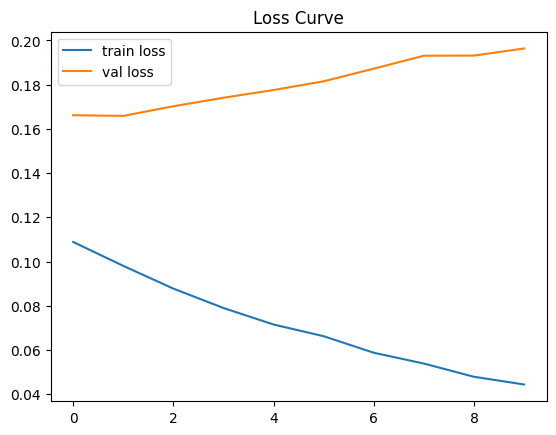

In [ ]:
# PLOT TRAINING CURVES
plt.plot(history_v2.history["loss"], label="train loss")
plt.plot(history_v2.history["val_loss"], label="val loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

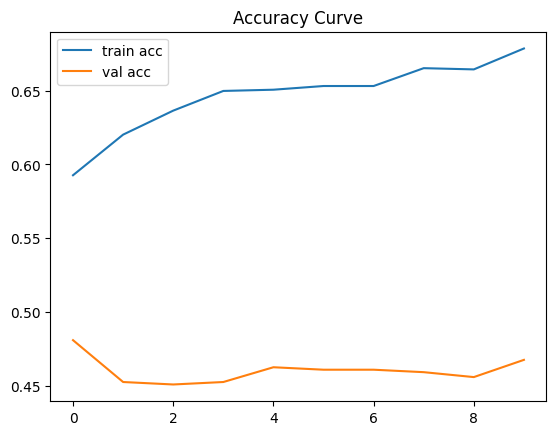

In [ ]:
plt.plot(history_v2.history["accuracy"], label="train acc")
plt.plot(history_v2.history["val_accuracy"], label="val acc")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

In [ ]:
y_pred_prob_v2 = model_v2.predict(X_val_pad)
y_pred_v2 = (y_pred_prob_v2 > 0.5).astype(int)

19/19 ━━━━━━━━━━━━━━━━━━━━ 14s 691ms/step


#### PREDICTIONS

In [ ]:
y_pred_prob_v2 = model.predict(X_val_pad)
y_pred_v2 = (y_pred_prob_v2 > 0.5).astype(int)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


#### MAIN METRIC: HAMMING LOSS

In [ ]:
hl = hamming_loss(y_val, y_pred_v2)
print("Hamming Loss:", hl)

Hamming Loss: 0.05979100970753725


#### FULL METRICS

In [ ]:
print("F1 (macro):", f1_score(y_val, y_pred_v2, average="macro"))
print("Precision:", precision_score(y_val, y_pred_v2, average="macro"))
print("Recall:", recall_score(y_val, y_pred_v2, average="macro"))
print("Accuracy:", accuracy_score(y_val, y_pred_v2))

F1 (macro): 0.35272985053831124
Precision: 0.49480991934837065
Recall: 0.29122327103462786
Accuracy: 0.2654424040066778


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#### CONFUSION MATRIX (PER LABEL)

In [ ]:
thresholds = np.arange(0.1, 0.9, 0.05)

best_t, best_score = 0, 1

for t in thresholds:
    preds = (y_pred_prob_v2 > t).astype(int)
    score = hamming_loss(y_val, preds)

    if score < best_score:
        best_score = score
        best_t = t

print("Best threshold:", best_t)
print("Best Hamming Loss:", best_score)

Best threshold: 0.6500000000000001
Best Hamming Loss: 0.05768874049341495


#### FINAL TEST PREDICTION

In [ ]:
test_seq = tokenizer.texts_to_sequences(df_test["clean_text"])
test_pad = pad_sequences(test_seq, maxlen=max_len, padding="post")

test_preds = model_v2.predict(test_pad)
test_labels = (test_preds > best_t).astype(int)

32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 530ms/step


## STEP 7: Critical Analysis of Results
Here we will then explain the Evaluation metrics for the experiments done to see where we have best results

# 7.7 Critical Analysis of Experimental Results

The objective of the traditional machine learning experiments was not only to identify the best-performing baseline model but also to understand how different feature representations and classification algorithms influence multi-label SDG indicator prediction. To ensure a comprehensive evaluation, multiple performance metrics were considered, including Hamming Loss, Accuracy, Precision, Recall, and F1-Score.

Because this project addresses a multi-label classification problem, relying on a single metric would provide an incomplete assessment of model performance. Different metrics capture different aspects of predictive behavior and therefore must be interpreted collectively.


## Comparative Analysis of Traditional Machine Learning Models

Table X summarizes the performance of all traditional machine learning experiments.

| Experiment | Representation | Model               | Hamming Loss | Accuracy | Precision | Recall | F1-Score |
| ---------- | -------------- | ------------------- | ------------ | -------- | --------- | ------ | -------- |
| 1          | TF-IDF         | Logistic Regression | 0.0532       | 0.2671   | 0.7178    | 0.1940 | 0.2873   |
| 2          | TF-IDF         | Linear SVM          | 0.0450       | 0.3756   | 0.8090    | 0.4288 | 0.5420   |
| 3          | TF-IDF         | Cosine Similarity   | 0.1716       | -        | -         | -      | -        |
| 4          | Word2Vec       | Logistic Regression | 0.0593       | 0.2254   | 0.4942    | 0.1600 | 0.2265   |
| 5          | Word2Vec       | Linear SVM          | 0.0577       | 0.2487   | 0.5188    | 0.1812 | 0.2508   |
| 6          | Word2Vec       | Cosine Similarity   | 0.9047       | -        | -         | -      | -        |

The results reveal several important patterns that provide insight into both the dataset and the effectiveness of the evaluated approaches.

## Impact of Feature Representation

- One of the most significant findings is the consistent superiority of TF-IDF representations over Word2Vec embeddings across all traditional machine learning models.

- For both Logistic Regression and Linear SVM, TF-IDF produced lower Hamming Loss values and substantially higher F1-scores. The performance difference was particularly pronounced for the Linear SVM classifier, where TF-IDF achieved a Hamming Loss of 0.0450 compared with 0.0577 for Word2Vec.

- This outcome initially appears counterintuitive because Word2Vec embeddings capture semantic relationships between words, whereas TF-IDF relies solely on term frequency statistics. However, the result can be explained by the characteristics of the dataset.

- Many SDG indicators are associated with highly specific terminology and recurring phrases. For example, indicators related to healthcare financing, medical research, disease prevention, and health workforce development often contain distinct keywords that directly signal the relevant SDG category. TF-IDF is particularly effective in such situations because it preserves these discriminative lexical patterns.

- Word2Vec embeddings, while semantically rich, compress information into lower-dimensional representations. This compression may inadvertently reduce the importance of highly informative keywords that are critical for distinguishing between closely related SDG indicators.

The findings therefore suggest that lexical specificity plays a more important role than semantic similarity in this classification task.

## Impact of Classification Algorithm

The choice of classification algorithm also had a substantial impact on performance.

For both TF-IDF and Word2Vec representations, Linear SVM consistently outperformed Logistic Regression across every evaluation metric.

When using TF-IDF features, the Linear SVM achieved the lowest Hamming Loss, highest accuracy, highest recall, and highest F1-score among all traditional models. The improvement in recall was particularly notable, increasing from 0.1940 to 0.4288.

This indicates that the Linear SVM was significantly better at identifying relevant SDG indicators without sacrificing precision.

The superior performance of the Linear SVM can be attributed to its ability to construct more effective decision boundaries within high-dimensional feature spaces. Since TF-IDF representations often contain thousands of sparse features, SVMs are generally well-suited to such environments.

The results suggest that classification performance is influenced not only by feature quality but also by the ability of the learning algorithm to exploit those features effectively.


## Performance of Similarity-Based Approaches

- Both cosine similarity experiments produced considerably weaker results than supervised learning models.

- The TF-IDF cosine similarity model achieved a Hamming Loss of 0.1716, while the Word2Vec cosine similarity model produced an extremely poor Hamming Loss of 0.9047.

- These results indicate that simple document similarity is insufficient for the SDG classification task. Although documents discussing similar topics may share common vocabulary or semantic content, the assignment of SDG indicators requires more nuanced understanding than nearest-neighbor retrieval can provide.

- The poor performance demonstrates that supervised learning is necessary to learn complex relationships between textual patterns and SDG indicators.

## Identification of the Best Baseline Model

- Among all traditional machine learning experiments, TF-IDF combined with Linear SVM emerged as the strongest baseline model.

- The model achieved the lowest Hamming Loss (0.0450), the highest accuracy (0.3756), the highest precision (0.8090), the highest recall (0.4288), and the highest F1-score (0.5420).

- These results indicate that the combination of sparse lexical features and a powerful linear classifier was particularly effective for the current dataset.

- Consequently, this configuration was selected as the benchmark against which subsequent deep learning experiments would be evaluated.

## Lessons Learned from Traditional Machine Learning Experiments

- Several important insights emerged from the baseline experimentation phase.

- First, feature representation plays a critical role in SDG classification performance. The strong performance of TF-IDF suggests that specific keywords and domain-specific terminology are highly informative indicators of SDG membership.

- Second, classifier selection significantly influences predictive quality. Linear SVM consistently demonstrated superior ability to exploit high-dimensional text representations compared with Logistic Regression.

- Third, semantic embeddings do not automatically guarantee improved performance. Despite their theoretical advantages, Word2Vec representations underperformed TF-IDF within the traditional machine learning setting, highlighting the importance of empirical evaluation rather than relying solely on theoretical expectations.

- Finally, the results established a strong baseline and provided valuable direction for the next stage of the project, namely the investigation of deep learning architectures capable of leveraging sequential information and richer semantic representations beyond what traditional models can capture.
